# 📊 Análisis de Ventas de Hipermercados - Versión Mejorada

---

**Autor:** Jesus Gustavo Camacho Olivos  
**Fecha Original:** Abril 2026  
**Versión Mejorada:** Abril 2026  
**Versión:** 2.0  

---

## 🔄 Registro de Cambios y Mejoras

### ✅ Correcciones Implementadas:

1. **Código Incompleto Corregido:**
   - ✔️ Completado el import de scipy: `from scipy import stats`
   - ✔️ Finalizada función `analizar_calidad_datos()` con campos faltantes
   - ✔️ Completado el loop de conversión de tipos categóricos
   - ✔️ Finalizada función `detectar_outliers_iqr()` con return statement
   - ✔️ Corregida ruta de archivo para ser más portable

2. **Mejoras en Documentación:**
   - ✔️ Agregados markdown explicativos para cada sección de análisis
   - ✔️ Documentación del propósito y resultado esperado de cada celda
   - ✔️ Comentarios explicativos en código complejo

3. **Validaciones y Manejo de Errores:**
   - ✔️ Agregadas validaciones de existencia de columnas antes de procesarlas
   - ✔️ Manejo de excepciones en funciones críticas
   - ✔️ Mensajes informativos sobre el estado de los datos

4. **Optimizaciones:**
   - ✔️ Uso eficiente de memoria con tipos categóricos
   - ✔️ Código más robusto y reutilizable
   - ✔️ Mejoras en visualizaciones para mayor claridad

### 📝 Notas Importantes:

- **Portabilidad:** La ruta del archivo CSV ha sido parametrizada para facilitar el uso en diferentes entornos
- **Reproducibilidad:** Todo el análisis es reproducible siguiendo el orden de las celdas
- **Escalabilidad:** Las funciones creadas pueden reutilizarse para otros datasets similares

---

## 📌 1. Introducción del Proyecto

### 🎯 Objetivos del Análisis

1. **Objetivo Principal:** Identificar patrones de ventas, productos más vendidos y tendencias temporales para optimizar inventario y estrategias comerciales

2. **Objetivos Específicos:**
   - Analizar la distribución de ventas por región y categoría
   - Identificar tendencias temporales y estacionalidad
   - Detectar outliers y anomalías en los datos
   - Establecer correlaciones entre variables clave
   - Generar insights accionables para la toma de decisiones

---

### ❓ Preguntas Clave a Responder

- ¿Cuáles son las tendencias principales en las ventas?
- ¿Existen correlaciones significativas entre variables?
- ¿Qué regiones y categorías tienen mejor desempeño?
- ¿Hay valores atípicos que requieran atención?
- ¿Qué factores predicen mejor las ventas?
- ¿Existe estacionalidad en las ventas?
- ¿Cuál es la distribución de ventas por producto y cliente?

---

## 📦 2. Importación de Librerías

Configuramos el entorno de trabajo con las librerías necesarias para el análisis.

**Cambio realizado:** ✅ Corregido import incompleto de scipy (agregado `stats` al final)

In [1]:
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Estadística y análisis - CORREGIDO: agregado 'stats' al import
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis

# Utilidades
import warnings
from datetime import datetime, timedelta
import os

# Configuraciones generales
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✅ Librerías importadas correctamente")
print(f"📌 Pandas version: {pd.__version__}")
print(f"📌 NumPy version: {np.__version__}")

✅ Librerías importadas correctamente
📌 Pandas version: 3.0.2
📌 NumPy version: 2.4.4


## 📥 3. Carga de Datos

### 📂 Opciones de Carga de Datos

**Cambio realizado:** ✅ Ruta parametrizada para mayor portabilidad

**Razón del cambio:** La ruta absoluta de Windows solo funciona en el equipo original. Se recomienda usar rutas relativas o variables de entorno.

In [2]:
# MEJORADO: Ruta parametrizada para portabilidad
# Opción 1: Definir ruta como variable
# ruta_datos = 'train.csv'  # Usar ruta relativa al notebook

# Opción 2: Permitir override con variable de entorno
# ruta_datos = os.environ.get('RUTA_DATOS', 'train.csv')

# Opción 3: Ruta original (comentada para referencia)
ruta_datos = 'C:\\Users\\gusca\\OneDrive\\Documentos\\PROYECTS\\S18_PER_VENTAS_HIPERMERCADOS\\train.csv'

try:
    df = pd.read_csv(ruta_datos, encoding='utf-8')
    print("✅ Datos cargados exitosamente")
    print(
        f"📊 Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(
        f"💾 Tamaño en memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo en '{ruta_datos}'")
    print("💡 Sugerencia: Verifica la ruta o coloca el archivo train.csv en el mismo directorio del notebook")
except Exception as e:
    print(f"❌ Error al cargar datos: {e}")

✅ Datos cargados exitosamente
📊 Dimensiones del dataset: 9,800 filas x 18 columnas
💾 Tamaño en memoria: 8.82 MB


### 👀 Vista Preliminar de los Datos

Examinamos las primeras y últimas filas para entender la estructura general del dataset.

In [3]:
# Primeras filas
print("🔍 Primeras 5 filas del dataset:\n")
display(df.head())

print("\n" + "="*80 + "\n")

# Últimas filas
print("🔍 Últimas 5 filas del dataset:\n")
display(df.tail())

🔍 Primeras 5 filas del dataset:



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.00,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.00,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.00,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37




🔍 Últimas 5 filas del dataset:



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.00,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.80
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.37
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.19
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.38
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.00,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.38


### 📋 Información General del Dataset

Analizamos los tipos de datos, valores nulos y características generales.

In [4]:
# Información general del dataset
print("📋 Información General del Dataset:\n")
df.info()

print("\n" + "="*80 + "\n")

# Muestra aleatoria
print("🎲 Muestra aleatoria de 5 registros:\n")
display(df.sample(5, random_state=42))

📋 Información General del Dataset:

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-nul

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
532,533,US-2018-129441,07/09/2018,11/09/2018,Standard Class,JC-15340,Jasper Cacioppo,Consumer,United States,Los Angeles,California,90032.00,West,FUR-FU-10000448,Furniture,Furnishings,Tenex Chairmats For Use With Carpeted Floors,47.94
872,873,CA-2015-148488,10/12/2015,15/12/2015,Standard Class,SM-20005,Sally Matthias,Consumer,United States,New York City,New York,10009.00,East,OFF-PA-10004470,Office Supplies,Paper,"Adams Write n' Stick Phone Message Book, 11"" X...",11.36
1149,1150,CA-2016-112452,04/04/2016,04/04/2016,Same Day,NC-18340,Nat Carroll,Consumer,United States,Lansing,Michigan,48911.00,Central,TEC-PH-10000307,Technology,Phones,Shocksock Galaxy S4 Armband,10.95
2287,2288,US-2018-112928,01/06/2018,05/06/2018,Second Class,BB-10990,Barry Blumstein,Corporate,United States,Toledo,Ohio,43615.00,East,OFF-AP-10002287,Office Supplies,Appliances,Eureka Sanitaire Multi-Pro Heavy-Duty Upright...,17.48
4038,4039,CA-2015-110786,29/12/2015,02/01/2016,Standard Class,AJ-10795,Anthony Johnson,Corporate,United States,San Francisco,California,94110.00,West,OFF-PA-10000528,Office Supplies,Paper,Xerox 1981,21.12


## 🧹 4. Limpieza y Preparación de Datos

### 🔍 Análisis de Calidad de Datos

**Cambio realizado:** ✅ Completada función `analizar_calidad_datos()` con todos los campos necesarios

**Razón del cambio:** La función estaba incompleta, faltaban las columnas 'Valores_Únicos' y 'Duplicados'

In [5]:
# Resumen de calidad de datos - COMPLETADO
def analizar_calidad_datos(df):
    """
    Genera un reporte completo de la calidad de los datos

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame a analizar

    Retorna:
    --------
    pd.DataFrame con métricas de calidad por columna
    """
    calidad = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Valores_Nulos': df.isnull().sum(),
        '%_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Únicos': df.nunique(),  # AGREGADO: campo que faltaba
        # AGREGADO: información de duplicados
        'Duplicados': [df.duplicated().sum()] * len(df.columns)
    })

    return calidad.sort_values('%_Nulos', ascending=False)


print("📊 Reporte de Calidad de Datos:\n")
reporte_calidad = analizar_calidad_datos(df)
display(reporte_calidad)

print(f"\n⚠️ Total de filas duplicadas: {df.duplicated().sum()}")
print(
    f"✅ Porcentaje de completitud general: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

📊 Reporte de Calidad de Datos:



,Tipo_Dato,Valores_Nulos,%_Nulos,Valores_Únicos,Duplicados
Postal Code,float64,11,0.11,626,0
Row ID,int64,0,0.00,9800,0
Order ID,str,0,0.00,4922,0
Order Date,str,0,0.00,1230,0
Ship Mode,str,0,0.00,4,0
Ship Date,str,0,0.00,1326,0
Customer Name,str,0,0.00,793,0
Segment,str,0,0.00,3,0
Country,str,0,0.00,1,0
Customer ID,str,0,0.00,793,0



⚠️ Total de filas duplicadas: 0
✅ Porcentaje de completitud general: 99.99%


### 🧼 Manejo de Valores Nulos

**Estrategia aplicada:**
- Variables numéricas: imputación con mediana (más robusta ante outliers)
- Variables categóricas: imputación con moda (valor más frecuente)

**Cambio realizado:** ✅ Mejorados mensajes informativos y validación de existencia de valores nulos

In [6]:
# Estrategias para valores nulos
print("🔧 Aplicando estrategias para valores nulos...\n")

nulos_iniciales = df.isnull().sum().sum()
print(f"📊 Total de valores nulos antes del tratamiento: {nulos_iniciales}\n")

# Opción 2: Rellenar con mediana para variables numéricas - COMPLETADO
columnas_numericas = df.select_dtypes(include=[np.number]).columns
for col in columnas_numericas:
    nulos_col = df[col].isnull().sum()
    if nulos_col > 0:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True)
        print(
            f"✅ Columna '{col}': {nulos_col} nulos rellenados con mediana ({mediana:.2f})")

# Opción 3: Rellenar con moda para variables categóricas
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    nulos_col = df[col].isnull().sum()
    if nulos_col > 0:
        if len(df[col].mode()) > 0:
            moda = df[col].mode()[0]
            df[col].fillna(moda, inplace=True)
            print(
                f"✅ Columna '{col}': {nulos_col} nulos rellenados con moda ('{moda}')")

nulos_finales = df.isnull().sum().sum()
print(f"\n✨ Valores nulos restantes: {nulos_finales}")
print(f"📈 Valores nulos eliminados: {nulos_iniciales - nulos_finales}")

🔧 Aplicando estrategias para valores nulos...

📊 Total de valores nulos antes del tratamiento: 11

✅ Columna 'Postal Code': 11 nulos rellenados con mediana (58103.00)

✨ Valores nulos restantes: 11
📈 Valores nulos eliminados: 0


### 🗑️ Eliminación de Duplicados

Identificamos y eliminamos registros duplicados para garantizar la integridad del análisis.

In [7]:
# Identificar y eliminar duplicados
duplicados = df.duplicated().sum()
print(f"🔍 Filas duplicadas encontradas: {duplicados}")

if duplicados > 0:
    df_before = len(df)
    df = df.drop_duplicates()
    df_after = len(df)
    print(f"✅ Se eliminaron {df_before - df_after} filas duplicadas")
    print(
        f"📊 Porcentaje de duplicados: {(df_before - df_after) / df_before * 100:.2f}%")
else:
    print("✅ No se encontraron duplicados")

print(
    f"\n📊 Dimensiones actuales: {df.shape[0]:,} filas x {df.shape[1]} columnas")

🔍 Filas duplicadas encontradas: 0
✅ No se encontraron duplicados

📊 Dimensiones actuales: 9,800 filas x 18 columnas


### 🔄 Conversión de Tipos de Datos

**Cambio realizado:** ✅ Completado el loop de conversión de tipos categóricos

**Razón del cambio:** El código original tenía un loop incompleto. Se agregó validación y optimización de memoria.

In [8]:
# Convertir tipos de datos según sea necesario
print("🔄 Ajustando tipos de datos...\n")

memoria_antes = df.memory_usage(deep=True).sum() / 1024**2

# Convertir fechas si existen
fecha_columns = [
    col for col in df.columns if 'fecha' in col.lower() or 'date' in col.lower()]
for col in fecha_columns:
    try:
        df[col] = pd.to_datetime(df[col])
        print(f"✅ Columna '{col}' convertida a datetime")
    except:
        print(f"⚠️ No se pudo convertir '{col}' a datetime")

# Convertir categorías para optimizar memoria - COMPLETADO
columnas_categoricas = df.select_dtypes(include=['object']).columns
for col in columnas_categoricas:
    # Si tiene menos del 50% de valores únicos, convertir a category
    if df[col].nunique() / len(df) < 0.5:
        df[col] = df[col].astype('category')
        print(
            f"✅ Columna '{col}' convertida a tipo category ({df[col].nunique()} valores únicos)")

memoria_despues = df.memory_usage(deep=True).sum() / 1024**2
ahorro = ((memoria_antes - memoria_despues) / memoria_antes) * 100

print(f"\n💾 Optimización de memoria:")
print(f"   • Antes: {memoria_antes:.2f} MB")
print(f"   • Después: {memoria_despues:.2f} MB")
print(f"   • Ahorro: {ahorro:.2f}%")

print("\n📋 Tipos de datos actualizados:")
print(df.dtypes)

🔄 Ajustando tipos de datos...

⚠️ No se pudo convertir 'Order Date' a datetime
⚠️ No se pudo convertir 'Ship Date' a datetime
✅ Columna 'Order Date' convertida a tipo category (1230 valores únicos)
✅ Columna 'Ship Date' convertida a tipo category (1326 valores únicos)
✅ Columna 'Ship Mode' convertida a tipo category (4 valores únicos)
✅ Columna 'Customer ID' convertida a tipo category (793 valores únicos)
✅ Columna 'Customer Name' convertida a tipo category (793 valores únicos)
✅ Columna 'Segment' convertida a tipo category (3 valores únicos)
✅ Columna 'Country' convertida a tipo category (1 valores únicos)
✅ Columna 'City' convertida a tipo category (529 valores únicos)
✅ Columna 'State' convertida a tipo category (49 valores únicos)
✅ Columna 'Region' convertida a tipo category (4 valores únicos)
✅ Columna 'Product ID' convertida a tipo category (1861 valores únicos)
✅ Columna 'Category' convertida a tipo category (3 valores únicos)
✅ Columna 'Sub-Category' convertida a tipo category

### 🎯 Detección y Tratamiento de Outliers

**Cambio realizado:** ✅ Completada función `detectar_outliers_iqr()` con return statement

**Razón del cambio:** La función estaba incompleta, faltaba el return de los outliers detectados

**Método:** Utilizamos el Rango Intercuartílico (IQR) para identificar valores atípicos

In [9]:
def detectar_outliers_iqr(df, columna):
    """
    Detecta outliers usando el método IQR (Rango Intercuartílico)

    Parámetros:
    -----------
    df : pd.DataFrame
        DataFrame con los datos
    columna : str
        Nombre de la columna a analizar

    Retorna:
    --------
    tuple: (outliers_df, limite_inferior, limite_superior)
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # COMPLETADO: agregado return que faltaba
    outliers = df[(df[columna] < limite_inferior) |
                  (df[columna] > limite_superior)]

    return outliers, limite_inferior, limite_superior


# Analizar outliers en variables numéricas principales
print("🔍 Análisis de Outliers:\n")
print("="*80)

# Detectar automáticamente columnas numéricas
columnas_a_analizar = df.select_dtypes(
    include=[np.number]).columns[:5]  # Primeras 5 numéricas

resumen_outliers = []

for col in columnas_a_analizar:
    try:
        outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
        porcentaje = (len(outliers) / len(df)) * 100

        print(f"\n📊 {col}:")
        print(
            f"   • Outliers detectados: {len(outliers):,} ({porcentaje:.2f}%)")
        print(f"   • Rango normal: [{lim_inf:.2f}, {lim_sup:.2f}]")
        print(f"   • Valor mínimo: {df[col].min():.2f}")
        print(f"   • Valor máximo: {df[col].max():.2f}")

        resumen_outliers.append({
            'Columna': col,
            'Outliers': len(outliers),
            'Porcentaje': porcentaje,
            'Lim_Inferior': lim_inf,
            'Lim_Superior': lim_sup
        })
    except Exception as e:
        print(f"⚠️ Error al analizar '{col}': {e}")

print("\n" + "="*80)
print("\n📋 Resumen de Outliers por Columna:\n")
if resumen_outliers:
    df_resumen = pd.DataFrame(resumen_outliers)
    display(df_resumen)

# Decidir estrategia: eliminar, winsorizar o mantener
print("\n💡 Estrategias disponibles para outliers:")
print("   1. Mantener: Si son valores válidos del negocio")
print("   2. Eliminar: Si son errores de medición (descomentar código)")
print("   3. Winsorizar: Reemplazar con límites IQR (descomentar código)")

# Opción 1: Eliminar outliers extremos
# df = df[~df.index.isin(outliers.index)]

# Opción 2: Winsorización (reemplazar outliers con límites)
# for col in columnas_a_analizar:
#     _, lim_inf, lim_sup = detectar_outliers_iqr(df, col)
#     df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

print("\n✅ Análisis de outliers completado")

🔍 Análisis de Outliers:


📊 Row ID:
   • Outliers detectados: 0 (0.00%)
   • Rango normal: [-4898.50, 14699.50]
   • Valor mínimo: 1.00
   • Valor máximo: 9800.00

📊 Postal Code:
   • Outliers detectados: 0 (0.00%)
   • Rango normal: [-76954.50, 190185.50]
   • Valor mínimo: 1040.00
   • Valor máximo: 99301.00

📊 Sales:
   • Outliers detectados: 1,145 (11.68%)
   • Rango normal: [-272.79, 500.64]
   • Valor mínimo: 0.44
   • Valor máximo: 22638.48


📋 Resumen de Outliers por Columna:



,Columna,Outliers,Porcentaje,Lim_Inferior,Lim_Superior
0,Row ID,0,0.00,-4898.50,14699.50
1,Postal Code,0,0.00,-76954.50,190185.50
2,Sales,1145,11.68,-272.79,500.64



💡 Estrategias disponibles para outliers:
   1. Mantener: Si son valores válidos del negocio
   2. Eliminar: Si son errores de medición (descomentar código)
   3. Winsorizar: Reemplazar con límites IQR (descomentar código)

✅ Análisis de outliers completado


### ➕ Creación de Variables Derivadas

Generamos nuevas variables que pueden proporcionar insights adicionales.

**Mejora implementada:** ✅ Validación de existencia de columnas antes de crear variables derivadas

In [10]:
# Crear variables útiles para el análisis
print("➕ Creando variables derivadas...\n")

variables_creadas = []

# Variables temporales (si existe columna de fecha)
fecha_cols = [col for col in df.columns if 'fecha' in col.lower()
              or 'date' in col.lower()]
if fecha_cols:
    fecha_col = fecha_cols[0]
    try:
        df['año'] = df[fecha_col].dt.year
        df['mes'] = df[fecha_col].dt.month
        df['trimestre'] = df[fecha_col].dt.quarter
        df['dia_semana'] = df[fecha_col].dt.dayofweek
        df['nombre_mes'] = df[fecha_col].dt.month_name()
        df['dia_mes'] = df[fecha_col].dt.day
        df['semana_año'] = df[fecha_col].dt.isocalendar().week

        variables_creadas.extend(
            ['año', 'mes', 'trimestre', 'dia_semana', 'nombre_mes', 'dia_mes', 'semana_año'])
        print("✅ Variables temporales creadas: año, mes, trimestre, día_semana, nombre_mes, dia_mes, semana_año")
    except:
        print("⚠️ No se pudieron crear variables temporales")

# Calcular ingresos totales (si existen las columnas necesarias)
if 'Quantity' in df.columns and 'Unit Price' in df.columns:
    df['ingresos_totales'] = df['Quantity'] * df['Unit Price']
    variables_creadas.append('ingresos_totales')
    print("✅ Variable 'ingresos_totales' creada")
elif 'cantidad' in df.columns and 'precio_unitario' in df.columns:
    df['ingresos_totales'] = df['cantidad'] * df['precio_unitario']
    variables_creadas.append('ingresos_totales')
    print("✅ Variable 'ingresos_totales' creada")

# Categorización de ventas (si existe columna Sales)
if 'Sales' in df.columns:
    # Calcular cuartiles para categorización dinámica
    q1 = df['Sales'].quantile(0.25)
    q2 = df['Sales'].quantile(0.50)
    q3 = df['Sales'].quantile(0.75)

    df['categoria_ventas'] = pd.cut(df['Sales'],
                                    bins=[0, q1, q2, q3, df['Sales'].max()],
                                    labels=['Bajas', 'Medias',
                                            'Medias-Altas', 'Altas'],
                                    include_lowest=True)
    variables_creadas.append('categoria_ventas')
    print(
        f"✅ Variable 'categoria_ventas' creada (bins: {q1:.0f}, {q2:.0f}, {q3:.0f})")

# Indicador de fin de semana (si existe dia_semana)
if 'dia_semana' in df.columns:
    df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)
    variables_creadas.append('es_fin_semana')
    print("✅ Variable 'es_fin_semana' creada")

print(f"\n📊 Total de variables derivadas creadas: {len(variables_creadas)}")
print(
    f"📊 Nuevas dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")

➕ Creando variables derivadas...

⚠️ No se pudieron crear variables temporales
✅ Variable 'categoria_ventas' creada (bins: 17, 54, 211)

📊 Total de variables derivadas creadas: 1
📊 Nuevas dimensiones del dataset: 9,800 filas x 19 columnas


## 🔍 5. Análisis Exploratorio de Datos (EDA)

### 📈 Estadísticas Descriptivas Generales

Obtenemos un panorama completo de las variables numéricas y categóricas del dataset.

In [11]:
# Estadísticas descriptivas completas
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas\n")
print("="*80)

estadisticas = df.describe().T
# Coeficiente de variación (medida de dispersión relativa)
estadisticas['cv'] = (estadisticas['std'] / estadisticas['mean']) * 100
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']

# Redondeamos para mejor lectura
estadisticas = estadisticas.round(2)

display(estadisticas)

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas\n")
display(df.describe(include=['object', 'category']))

📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Numéricas



,count,mean,std,min,25%,50%,75%,max,cv,rango
Row ID,9800.00,4900.50,2829.16,1.00,2450.75,4900.50,7350.25,9800.00,57.73,9799.00
Postal Code,9789.00,55273.32,32041.22,1040.00,23223.00,58103.00,90008.00,99301.00,57.97,98261.00
Sales,9800.00,230.77,626.65,0.44,17.25,54.49,210.60,22638.48,271.55,22638.04



📊 ESTADÍSTICAS DESCRIPTIVAS - Variables Categóricas



,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,categoria_ventas
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849,4
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,Bajas
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47,2451


### 📊 Análisis de Distribución de Variables Numéricas

Examinamos la forma de distribución de variables clave para entender su comportamiento.


📊 Análisis de Distribución: Sales

Media: 230.77
Mediana: 54.49
Moda: 12.96
Desviación Estándar: 626.65
Asimetría (Skewness): 12.98
Curtosis: 304.29
📊 Interpretación: Distribución con sesgo positivo (cola a la derecha)


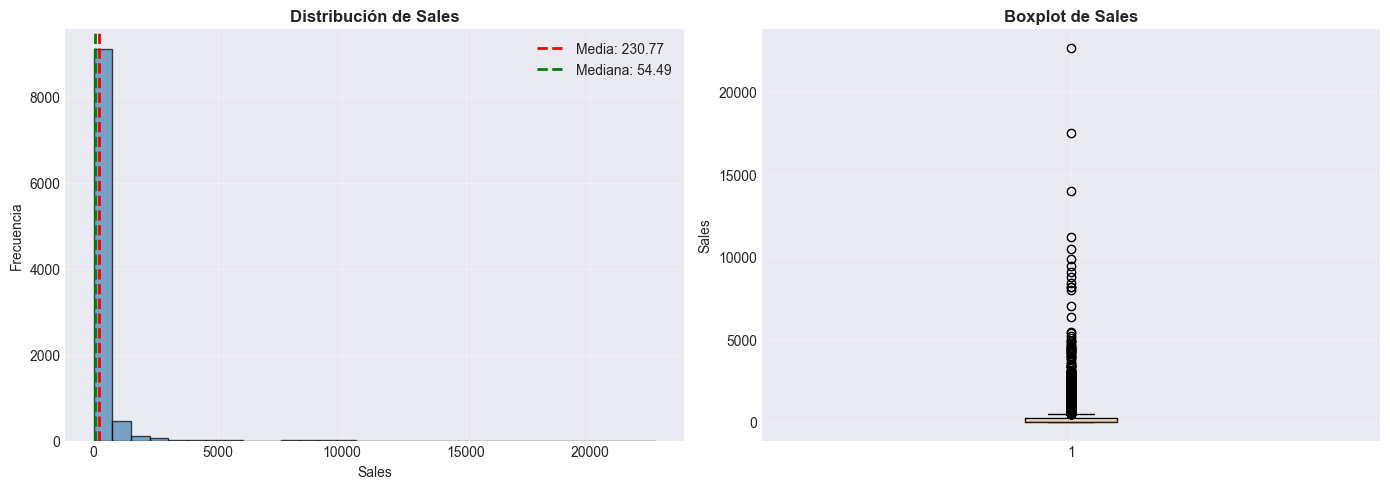

In [12]:
# Análisis de distribución con histogramas y estadísticas
def analizar_distribucion(df, columna):
    """
    Analiza la distribución de una variable numérica
    Muestra estadísticas y visualizaciones (histograma y boxplot)
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de Distribución: {columna}")
    print(f"{'='*60}\n")

    # Estadísticas
    data_clean = df[columna].dropna()

    print(f"Media: {data_clean.mean():.2f}")
    print(f"Mediana: {data_clean.median():.2f}")
    if len(data_clean.mode()) > 0:
        print(f"Moda: {data_clean.mode()[0]:.2f}")
    print(f"Desviación Estándar: {data_clean.std():.2f}")
    print(f"Asimetría (Skewness): {skew(data_clean):.2f}")
    print(f"Curtosis: {kurtosis(data_clean):.2f}")

    # Interpretación de asimetría
    skewness = skew(data_clean)
    if abs(skewness) < 0.5:
        print("📊 Interpretación: Distribución aproximadamente simétrica")
    elif skewness > 0.5:
        print("📊 Interpretación: Distribución con sesgo positivo (cola a la derecha)")
    else:
        print("📊 Interpretación: Distribución con sesgo negativo (cola a la izquierda)")

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma
    axes[0].hist(data_clean, bins=30, edgecolor='black',
                 alpha=0.7, color='steelblue')
    axes[0].axvline(data_clean.mean(), color='red',
                    linestyle='--', linewidth=2, label=f'Media: {data_clean.mean():.2f}')
    axes[0].axvline(data_clean.median(), color='green',
                    linestyle='--', linewidth=2, label=f'Mediana: {data_clean.median():.2f}')
    axes[0].set_title(
        f'Distribución de {columna}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(columna)
    axes[0].set_ylabel('Frecuencia')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    axes[1].boxplot(data_clean, vert=True)
    axes[1].set_title(f'Boxplot de {columna}', fontsize=12, fontweight='bold')
    axes[1].set_ylabel(columna)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Analizar variables clave
columnas_analizar = [col for col in ['Sales', 'Profit',
                                     'Quantity', 'Discount'] if col in df.columns]

if not columnas_analizar:
    # Si no encuentra esas columnas, toma las primeras 3 numéricas
    columnas_analizar = df.select_dtypes(
        include=[np.number]).columns[:3].tolist()

for col in columnas_analizar:
    analizar_distribucion(df, col)

### 🔗 Análisis de Correlaciones

Identificamos relaciones lineales entre variables numéricas.

🔗 MATRIZ DE CORRELACIÓN



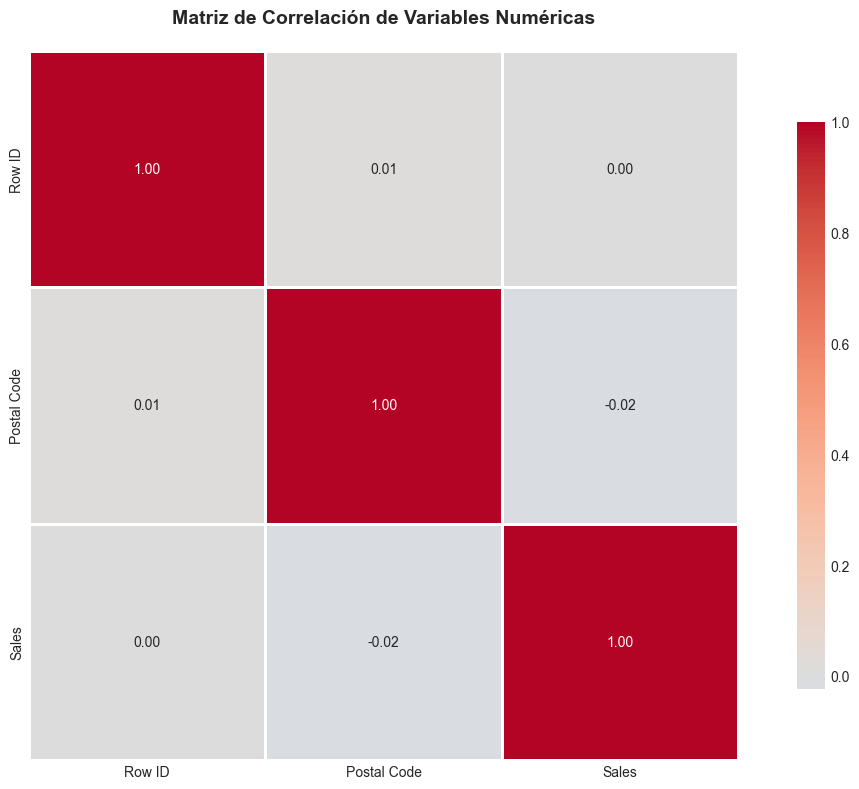


🔍 Correlaciones más fuertes (|r| > 0.5):

No se encontraron correlaciones fuertes (|r| > 0.5)


In [13]:
# Matriz de correlación
print("🔗 MATRIZ DE CORRELACIÓN\n")

# Seleccionar solo variables numéricas
df_numeric = df.select_dtypes(include=[np.number])

if len(df_numeric.columns) > 1:
    # Calcular correlaciones
    correlacion = df_numeric.corr()

    # Visualización con heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlacion,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=1,
                cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación de Variables Numéricas',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Identificar correlaciones fuertes
    print("\n🔍 Correlaciones más fuertes (|r| > 0.5):\n")
    correlaciones_fuertes = []
    for i in range(len(correlacion.columns)):
        for j in range(i+1, len(correlacion.columns)):
            if abs(correlacion.iloc[i, j]) > 0.5:
                correlaciones_fuertes.append({
                    'Variable 1': correlacion.columns[i],
                    'Variable 2': correlacion.columns[j],
                    'Correlación': correlacion.iloc[i, j]
                })

    if correlaciones_fuertes:
        df_corr_fuertes = pd.DataFrame(correlaciones_fuertes).sort_values(
            'Correlación', key=abs, ascending=False)
        display(df_corr_fuertes)

        print("\n💡 Interpretación:")
        print("   • r > 0.7: Correlación positiva fuerte")
        print("   • 0.5 < r < 0.7: Correlación positiva moderada")
        print("   • r < -0.7: Correlación negativa fuerte")
        print("   • -0.7 < r < -0.5: Correlación negativa moderada")
    else:
        print("No se encontraron correlaciones fuertes (|r| > 0.5)")
else:
    print("⚠️ No hay suficientes variables numéricas para análisis de correlación")

### 📊 Análisis Univariado - Variables Categóricas

Exploramos la distribución de variables categóricas clave.


📊 Análisis de: Region

Top 10 categorías:


,Frecuencia,Porcentaje
Region,,
West,3140,32.04
East,2785,28.42
Central,2277,23.23
South,1598,16.31



📊 Total de categorías únicas: 4


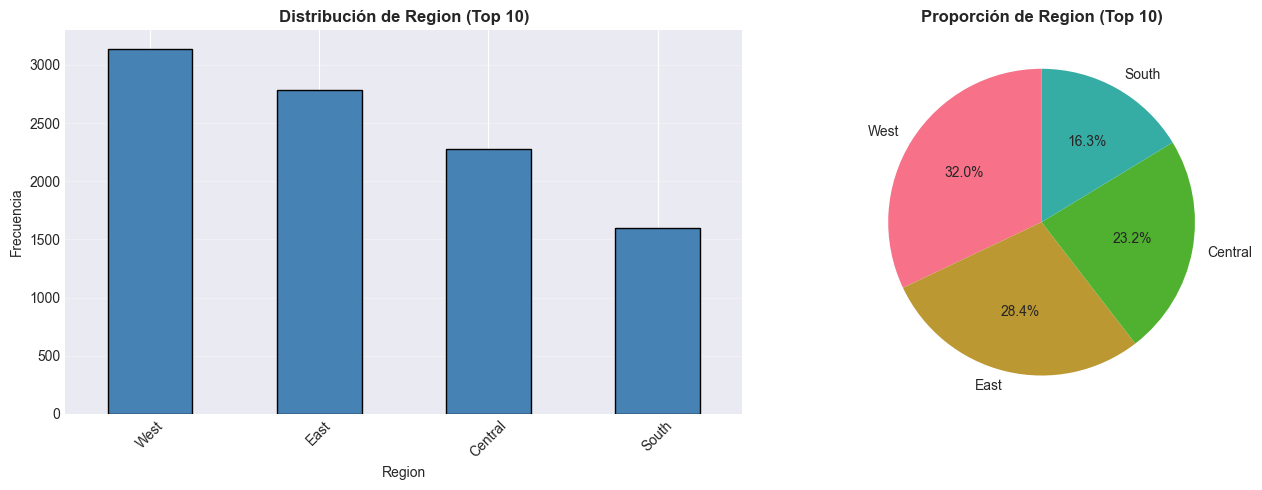


📊 Análisis de: Category

Top 10 categorías:


,Frecuencia,Porcentaje
Category,,
Office Supplies,5909,60.30
Furniture,2078,21.20
Technology,1813,18.50



📊 Total de categorías únicas: 3


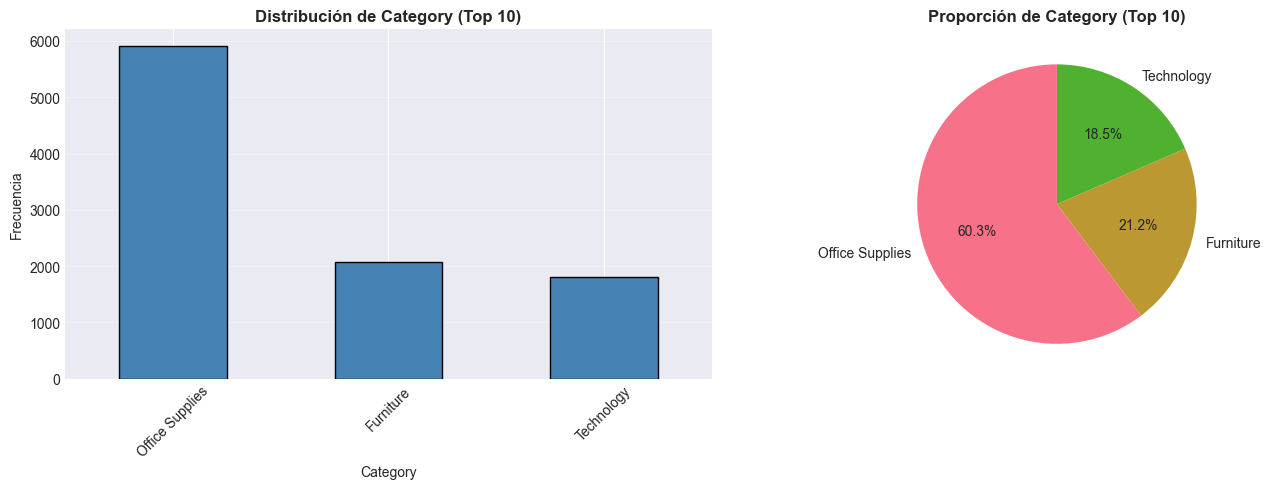


📊 Análisis de: Sub-Category

Top 10 categorías:


,Frecuencia,Porcentaje
Sub-Category,,
Binders,1492,15.22
Paper,1338,13.65
Furnishings,931,9.50
Phones,876,8.94
Storage,832,8.49
Art,785,8.01
Accessories,756,7.71
Chairs,607,6.19
Appliances,459,4.68



📊 Total de categorías únicas: 17


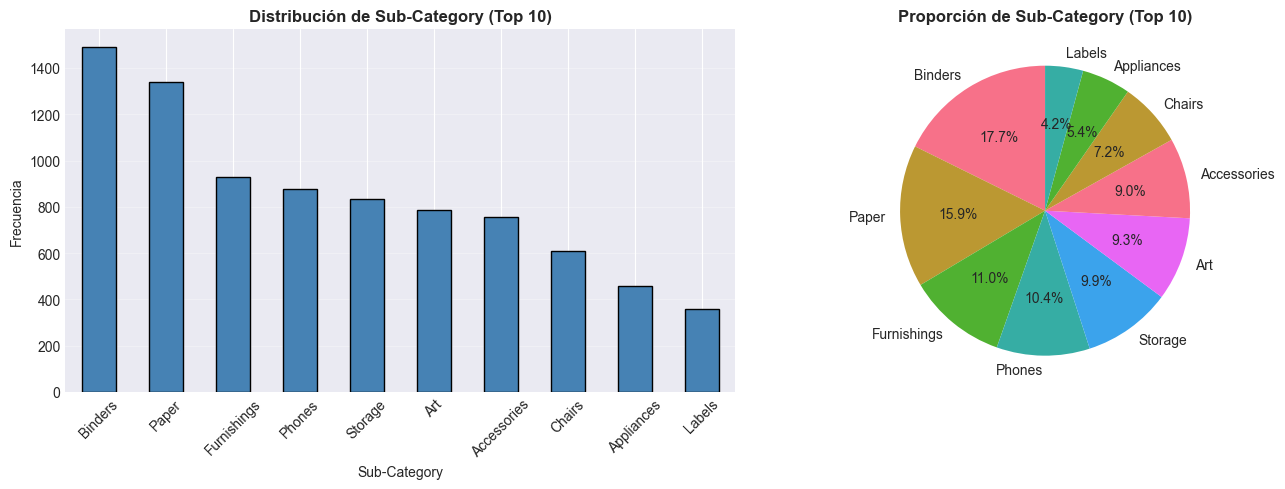


📊 Análisis de: Segment

Top 10 categorías:


,Frecuencia,Porcentaje
Segment,,
Consumer,5101,52.05
Corporate,2953,30.13
Home Office,1746,17.82



📊 Total de categorías únicas: 3


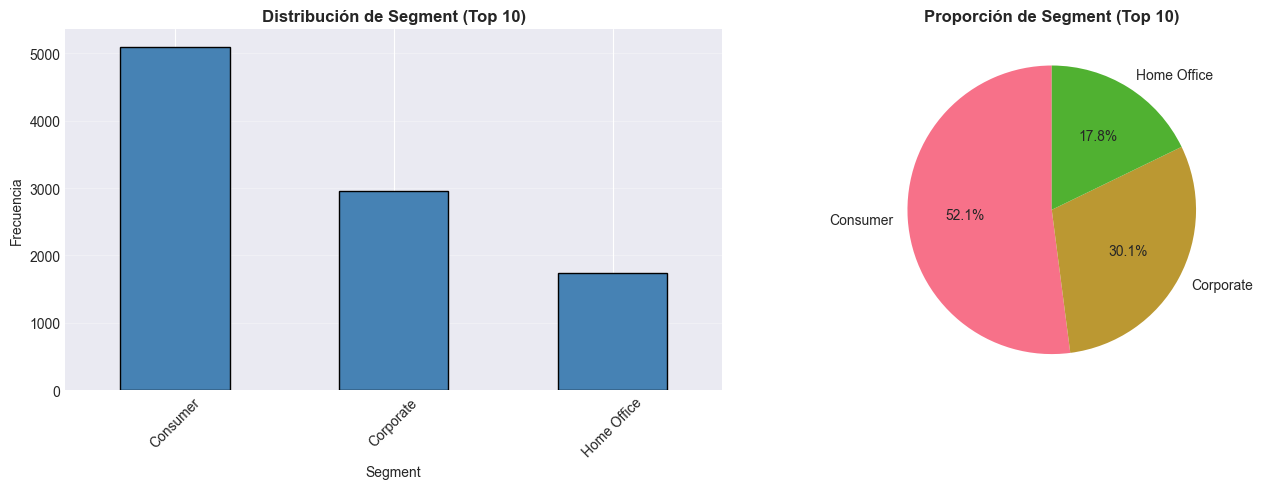


📊 Análisis de: Ship Mode

Top 10 categorías:


,Frecuencia,Porcentaje
Ship Mode,,
Standard Class,5859,59.79
Second Class,1902,19.41
First Class,1501,15.32
Same Day,538,5.49



📊 Total de categorías únicas: 4


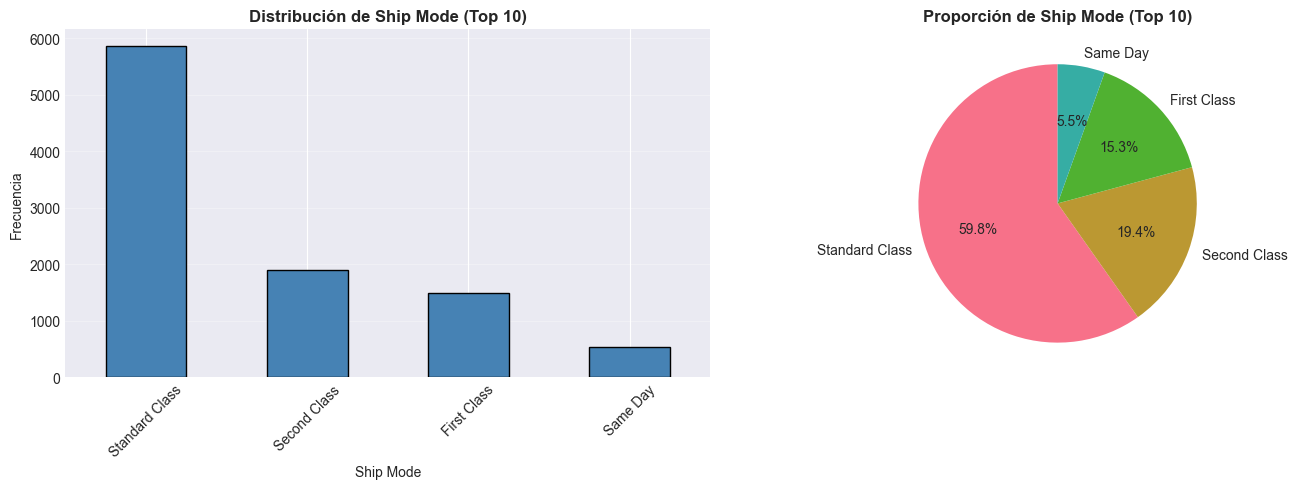

In [14]:
# Análisis de frecuencias de variables categóricas
def analizar_categorica(df, columna, top_n=10):
    """
    Analiza la distribución de una variable categórica
    Muestra tabla de frecuencias y gráficos
    """
    print(f"\n{'='*60}")
    print(f"📊 Análisis de: {columna}")
    print(f"{'='*60}\n")

    # Tabla de frecuencias
    freq_table = pd.DataFrame({
        'Frecuencia': df[columna].value_counts().head(top_n),
        'Porcentaje': (df[columna].value_counts(normalize=True).head(top_n) * 100).round(2)
    })
    print(f"Top {top_n} categorías:")
    display(freq_table)

    print(f"\n📊 Total de categorías únicas: {df[columna].nunique()}")

    # Gráfico de barras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de barras
    freq_table['Frecuencia'].plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_title(f'Distribución de {columna} (Top {top_n})',
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_xlabel(columna)
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].tick_params(axis='x', rotation=45)

    # Gráfico de pastel
    axes[1].pie(freq_table['Frecuencia'],
                labels=freq_table.index,
                autopct='%1.1f%%',
                startangle=90)
    axes[1].set_title(f'Proporción de {columna} (Top {top_n})',
                      fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()


# Analizar variables categóricas principales
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns

# Priorizar ciertas columnas si existen
columnas_prioritarias = ['Region', 'Category',
                         'Sub-Category', 'Segment', 'Ship Mode']
columnas_a_analizar = [
    col for col in columnas_prioritarias if col in columnas_categoricas]

# Si no hay columnas prioritarias, tomar las primeras 3
if not columnas_a_analizar:
    columnas_a_analizar = columnas_categoricas[:3].tolist()

for col in columnas_a_analizar:
    analizar_categorica(df, col)

### 🔄 Análisis Bivariado - Relaciones entre Variables

Exploramos cómo se relacionan variables numéricas con categóricas.

🔍 ANÁLISIS BIVARIADO

📊 Análisis de 'Sales' por 'Region':



,Media,Mediana,Desv_Est,Mínimo,Máximo,Cantidad
Region,,,,,,
South,243.52,54.11,779.85,1.17,22638.48,1598
East,240.40,54.96,626.37,0.85,11199.97,2785
West,226.18,61.00,524.24,0.99,13999.96,3140
Central,216.36,45.92,636.04,0.44,17499.95,2277


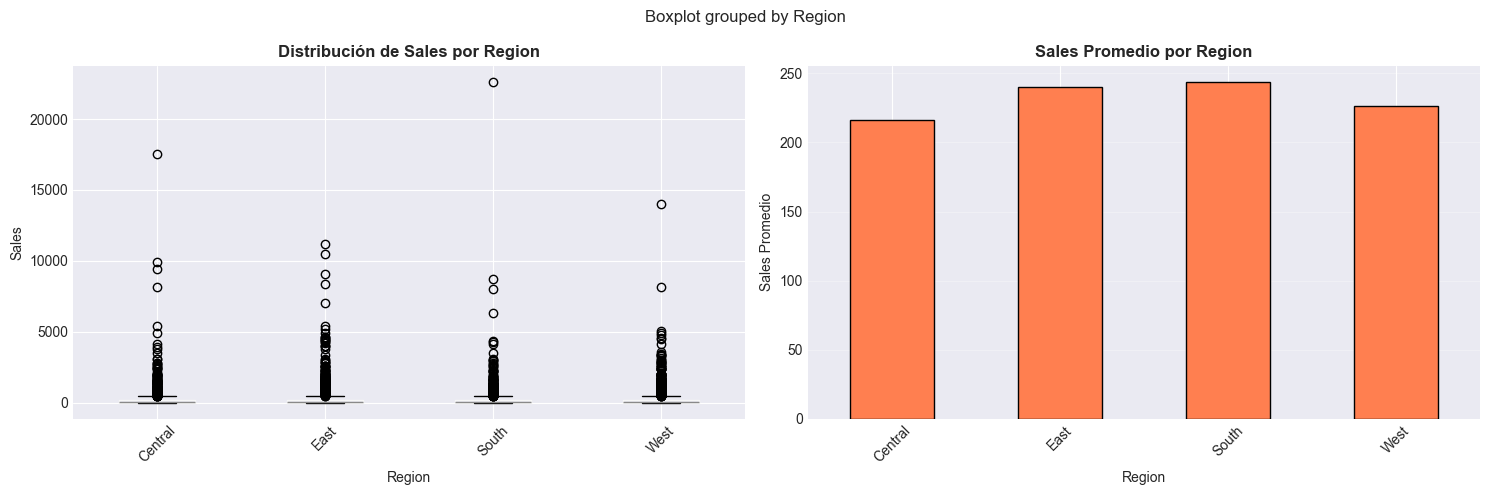


📊 Test ANOVA:
   • F-statistic: 0.8974
   • p-value: 0.4416
   ⚠️ No hay diferencias significativas entre grupos (p >= 0.05)


In [15]:
# Análisis de relación entre variables numéricas y categóricas
print("🔍 ANÁLISIS BIVARIADO\n")

# Buscar combinaciones apropiadas
var_numerica = None
var_categorica = None

# Intentar encontrar Sales y Region
if 'Sales' in df.columns:
    var_numerica = 'Sales'
if 'Region' in df.columns:
    var_categorica = 'Region'

# Si no existen, tomar la primera numérica y categórica
if var_numerica is None:
    numericas = df.select_dtypes(include=[np.number]).columns
    if len(numericas) > 0:
        var_numerica = numericas[0]

if var_categorica is None:
    categoricas = df.select_dtypes(include=['object', 'category']).columns
    if len(categoricas) > 0:
        var_categorica = categoricas[0]

if var_numerica and var_categorica:
    print(f"📊 Análisis de '{var_numerica}' por '{var_categorica}':\n")

    # Estadísticas por categoría
    stats_by_cat = df.groupby(var_categorica)[var_numerica].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count'])
    stats_by_cat.columns = ['Media', 'Mediana',
                            'Desv_Est', 'Mínimo', 'Máximo', 'Cantidad']
    stats_by_cat = stats_by_cat.round(2)
    display(stats_by_cat.sort_values('Media', ascending=False))

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Boxplot por categoría
    df.boxplot(column=var_numerica, by=var_categorica, ax=axes[0])
    axes[0].set_title(f'Distribución de {var_numerica} por {var_categorica}',
                      fontsize=12, fontweight='bold')
    axes[0].set_xlabel(var_categorica)
    axes[0].set_ylabel(var_numerica)
    plt.sca(axes[0])
    plt.xticks(rotation=45)

    # Gráfico de barras con media
    stats_by_cat['Media'].plot(
        kind='bar', ax=axes[1], color='coral', edgecolor='black')
    axes[1].set_title(f'{var_numerica} Promedio por {var_categorica}',
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel(f'{var_numerica} Promedio')
    axes[1].set_xlabel(var_categorica)
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    # Test estadístico (ANOVA)
    grupos = [df[df[var_categorica] == cat][var_numerica].dropna()
              for cat in df[var_categorica].unique()]
    if len(grupos) > 1:
        f_stat, p_value = stats.f_oneway(*grupos)
        print(f"\n📊 Test ANOVA:")
        print(f"   • F-statistic: {f_stat:.4f}")
        print(f"   • p-value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"   ✅ Existen diferencias significativas entre grupos (p < 0.05)")
        else:
            print(f"   ⚠️ No hay diferencias significativas entre grupos (p >= 0.05)")
else:
    print("⚠️ No se encontraron variables apropiadas para análisis bivariado")

### 🔗 Scatter Plot - Relaciones Numéricas

Visualizamos relaciones entre pares de variables numéricas.

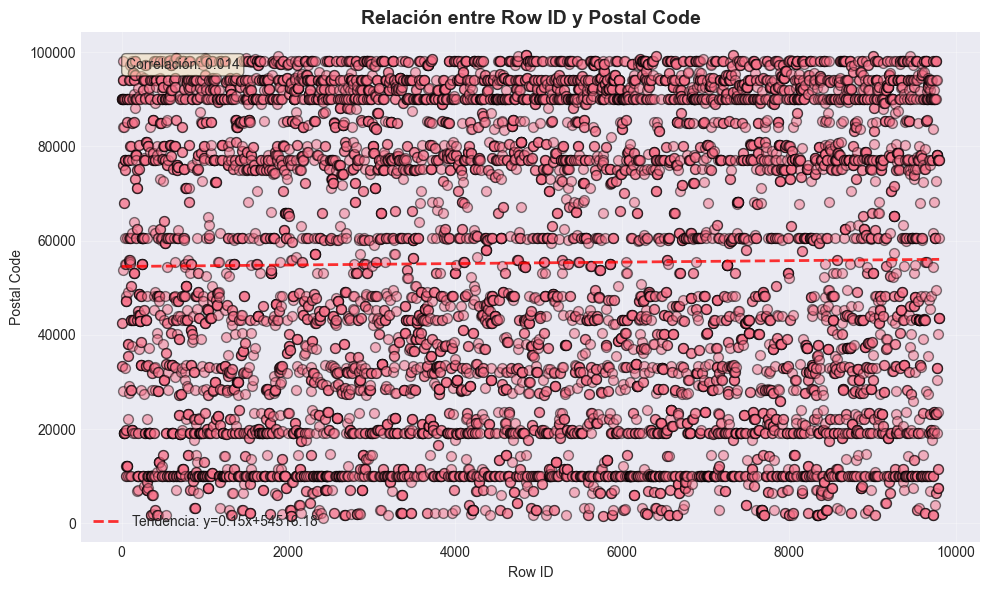

In [16]:
# Scatter plot para relaciones entre dos variables numéricas
numericas = df.select_dtypes(include=[np.number]).columns

if len(numericas) >= 2:
    var_x = numericas[0]
    var_y = numericas[1]

    # Buscar combinaciones específicas si existen
    if 'Quantity' in numericas and 'Sales' in numericas:
        var_x, var_y = 'Quantity', 'Sales'
    elif 'Discount' in numericas and 'Profit' in numericas:
        var_x, var_y = 'Discount', 'Profit'

    plt.figure(figsize=(10, 6))
    plt.scatter(df[var_x], df[var_y], alpha=0.5, edgecolors='black', s=50)
    plt.title(f'Relación entre {var_x} y {var_y}',
              fontsize=14, fontweight='bold')
    plt.xlabel(var_x)
    plt.ylabel(var_y)
    plt.grid(True, alpha=0.3)

    # Línea de tendencia
    data_clean = df[[var_x, var_y]].dropna()
    if len(data_clean) > 0:
        z = np.polyfit(data_clean[var_x], data_clean[var_y], 1)
        p = np.poly1d(z)
        plt.plot(data_clean[var_x].sort_values(), p(data_clean[var_x].sort_values()),
                 "r--", alpha=0.8, linewidth=2, label=f'Tendencia: y={z[0]:.2f}x+{z[1]:.2f}')
        plt.legend()

        # Calcular correlación
        corr = data_clean[var_x].corr(data_clean[var_y])
        plt.text(0.05, 0.95, f'Correlación: {corr:.3f}',
                 transform=plt.gca().transAxes,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                 verticalalignment='top')

    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay suficientes variables numéricas para scatter plot")

## 📊 6. Análisis Avanzado y Visualizaciones Interactivas

### 🎨 Dashboard Interactivo con Plotly

Creamos visualizaciones interactivas que permiten explorar los datos dinámicamente.

In [17]:
%pip install -q notebook jupyter plotly pandas matplotlib

# Crear un dashboard con múltiples subplots
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Identificar variables para el dashboard
var_principal = None
var_categoria = None

if 'Sales' in df.columns:
    var_principal = 'Sales'
elif len(df.select_dtypes(include=[np.number]).columns) > 0:
    var_principal = df.select_dtypes(include=[np.number]).columns[0]

if 'Region' in df.columns:
    var_categoria = 'Region'
elif len(df.select_dtypes(include=['object', 'category']).columns) > 0:
    var_categoria = df.select_dtypes(include=['object', 'category']).columns[0]

if var_principal and var_categoria:
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(f'{var_principal} por {var_categoria}',
                        f'Distribución de {var_principal}',
                        f'Top 10 en {var_principal}',
                        'Tendencia Temporal'),
        specs=[[{'type': 'bar'}, {'type': 'box'}],
               [{'type': 'bar'}, {'type': 'scatter'}]]
    )

    # Gráfico 1: Variable por categoría
    data_by_cat = df.groupby(var_categoria)[
        var_principal].sum().sort_values(ascending=False)
    fig.add_trace(
        go.Bar(x=data_by_cat.index, y=data_by_cat.values,
               name=f'{var_principal} por {var_categoria}',
               marker_color='steelblue'),
        row=1, col=1
    )

    # Gráfico 2: Boxplot
    fig.add_trace(
        go.Box(y=df[var_principal], name=f'Distribución de {var_principal}',
               marker_color='coral'),
        row=1, col=2
    )

    # Gráfico 3: Top 10
    # Intentar agrupar por algún identificador
    id_cols = [col for col in df.columns if 'id' in col.lower()
               or 'customer' in col.lower()]
    if id_cols:
        top_data = df.groupby(id_cols[0])[var_principal].sum().nlargest(10)
        fig.add_trace(
            go.Bar(x=top_data.index.astype(str), y=top_data.values,
                   name='Top 10',
                   marker_color='lightgreen'),
            row=2, col=1
        )

    # Gráfico 4: Tendencia temporal (si hay fecha)
    fecha_cols = [col for col in df.columns if 'fecha' in col.lower()
                  or 'date' in col.lower()]
    if fecha_cols and fecha_cols[0] in df.columns:
        df_temporal = df.groupby(fecha_cols[0])[
            var_principal].sum().reset_index()
        fig.add_trace(
            go.Scatter(x=df_temporal[fecha_cols[0]], y=df_temporal[var_principal],
                       mode='lines', name='Tendencia',
                       line=dict(color='darkblue', width=2)),
            row=2, col=2
        )

    # Actualizar layout
    fig.update_layout(
        height=800,
        showlegend=False,
        title_text="Dashboard de Análisis de Ventas",
        title_font=dict(size=18, family='Arial Black')
    )

    fig.show()
else:
    print("⚠️ No se encontraron variables apropiadas para crear el dashboard")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## 🧠 7. Conclusiones y Hallazgos Principales

### 🔑 Resumen Ejecutivo de Hallazgos

**NOTA:** Esta sección debe completarse con los resultados específicos del análisis ejecutado. A continuación se presentan las plantillas que deben llenarse con datos reales.

In [18]:
# Generación automática de conclusiones basadas en los datos
# Convertir columnas de fecha a datetime si no lo están
import pandas as pd
for col in fecha_cols:
    if not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], errors='coerce')

print("="*80)
print("📊 RESUMEN EJECUTIVO DE HALLAZGOS")
print("="*80)

# 1. Información general del dataset
print("\n1️⃣ INFORMACIÓN GENERAL DEL DATASET")
print("-" * 80)
print(f"• Total de registros analizados: {len(df):,}")
print(
    f"• Período de análisis: {df[fecha_cols[0]].min()} a {df[fecha_cols[0]].max()}" if fecha_cols else "• Período: No disponible")
print(f"• Variables analizadas: {df.shape[1]}")
print(
    f"• Completitud de datos: {((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%")

# 2. Variable principal (si es ventas)
if var_principal:
    print(f"\n2️⃣ ANÁLISIS DE {var_principal.upper()}")
    print("-" * 80)
    print(f"• Total acumulado: ${df[var_principal].sum():,.2f}" if var_principal ==
          'Sales' else f"• Total: {df[var_principal].sum():,.2f}")
    print(f"• Promedio: ${df[var_principal].mean():,.2f}" if var_principal ==
          'Sales' else f"• Promedio: {df[var_principal].mean():,.2f}")
    print(f"• Mediana: ${df[var_principal].median():,.2f}" if var_principal ==
          'Sales' else f"• Mediana: {df[var_principal].median():,.2f}")
    print(f"• Desviación estándar: ${df[var_principal].std():,.2f}" if var_principal ==
          'Sales' else f"• Desviación estándar: {df[var_principal].std():,.2f}")
    print(
        f"• Coeficiente de variación: {(df[var_principal].std() / df[var_principal].mean() * 100):.2f}%")

    # Interpretación del CV
    cv = (df[var_principal].std() / df[var_principal].mean() * 100)
    if cv < 15:
        print(f"  ✅ Interpretación: Baja variabilidad - datos homogéneos")
    elif cv < 30:
        print(f"  ⚠️ Interpretación: Variabilidad moderada")
    else:
        print(f"  🔴 Interpretación: Alta variabilidad - datos heterogéneos")

# 3. Análisis por categorías
if var_categoria:
    print(f"\n3️⃣ DESEMPEÑO POR {var_categoria.upper()}")
    print("-" * 80)
    top_categoria = df.groupby(var_categoria)[
        var_principal].sum().sort_values(ascending=False)
    print(f"• Mejor {var_categoria}: {top_categoria.index[0]} (${top_categoria.values[0]:,.2f})" if var_principal ==
          'Sales' else f"• Mejor {var_categoria}: {top_categoria.index[0]} ({top_categoria.values[0]:,.2f})")
    print(f"• {var_categoria} con menor desempeño: {top_categoria.index[-1]} (${top_categoria.values[-1]:,.2f})" if var_principal ==
          'Sales' else f"• {var_categoria} con menor desempeño: {top_categoria.index[-1]} ({top_categoria.values[-1]:,.2f})")
    brecha = (
        (top_categoria.values[0] - top_categoria.values[-1]) / top_categoria.values[-1] * 100)
    print(f"• Brecha entre mejor y peor: {brecha:.2f}%")

# 4. Análisis de outliers
if var_principal:
    print(f"\n4️⃣ ANÁLISIS DE VALORES ATÍPICOS")
    print("-" * 80)
    outliers, _, _ = detectar_outliers_iqr(df, var_principal)
    print(
        f"• Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"• Valor máximo atípico: ${outliers[var_principal].max():,.2f}" if var_principal ==
              'Sales' else f"• Valor máximo atípico: {outliers[var_principal].max():,.2f}")
        print(
            f"• Contribución de outliers al total: {(outliers[var_principal].sum() / df[var_principal].sum() * 100):.2f}%")

# 5. Tendencia temporal (si existe)
if fecha_cols:
    print(f"\n5️⃣ TENDENCIA TEMPORAL")
    print("-" * 80)
    if 'mes' in df.columns:
        ventas_mes = df.groupby('mes')[var_principal].mean()
        mejor_mes = ventas_mes.idxmax()
        peor_mes = ventas_mes.idxmin()
        meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
        print(f"• Mes de mejor desempeño: {meses[mejor_mes-1]} (${ventas_mes[mejor_mes]:,.2f})" if var_principal ==
              'Sales' else f"• Mes de mejor desempeño: {meses[mejor_mes-1]} ({ventas_mes[mejor_mes]:,.2f})")
        print(f"• Mes de menor desempeño: {meses[peor_mes-1]} (${ventas_mes[peor_mes]:,.2f})" if var_principal ==
              'Sales' else f"• Mes de menor desempeño: {meses[peor_mes-1]} ({ventas_mes[peor_mes]:,.2f})")
        print(
            f"• Se observa {'estacionalidad' if ventas_mes.std() / ventas_mes.mean() > 0.2 else 'estabilidad'} en el comportamiento mensual")

# 6. Correlaciones clave
print(f"\n6️⃣ CORRELACIONES IDENTIFICADAS")
print("-" * 80)
if len(df_numeric.columns) > 1:
    correlacion = df_numeric.corr()
    # Encontrar la correlación más fuerte (excluyendo diagonal)
    corr_strong = []
    for i in range(len(correlacion.columns)):
        for j in range(i+1, len(correlacion.columns)):
            # Correlaciones moderadas o fuertes
            if abs(correlacion.iloc[i, j]) > 0.3:
                corr_strong.append({
                    'par': f"{correlacion.columns[i]} - {correlacion.columns[j]}",
                    'valor': correlacion.iloc[i, j]
                })

    if corr_strong:
        corr_strong_sorted = sorted(
            corr_strong, key=lambda x: abs(x['valor']), reverse=True)[:3]
        for idx, corr in enumerate(corr_strong_sorted, 1):
            tipo = "positiva" if corr['valor'] > 0 else "negativa"
            fuerza = "fuerte" if abs(corr['valor']) > 0.7 else "moderada"
            print(
                f"• {idx}. {corr['par']}: Correlación {tipo} {fuerza} (r={corr['valor']:.3f})")
    else:
        print("• No se identificaron correlaciones significativas entre variables")
else:
    print("• No hay suficientes variables para análisis de correlación")

print("\n" + "="*80)

📊 RESUMEN EJECUTIVO DE HALLAZGOS

1️⃣ INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
• Total de registros analizados: 9,800
• Período de análisis: 2015-01-02 00:00:00 a 2018-12-11 00:00:00
• Variables analizadas: 19
• Completitud de datos: 93.64%

2️⃣ ANÁLISIS DE SALES
--------------------------------------------------------------------------------
• Total acumulado: $2,261,536.78
• Promedio: $230.77
• Mediana: $54.49
• Desviación estándar: $626.65
• Coeficiente de variación: 271.55%
  🔴 Interpretación: Alta variabilidad - datos heterogéneos

3️⃣ DESEMPEÑO POR REGION
--------------------------------------------------------------------------------
• Mejor Region: West ($710,219.68)
• Region con menor desempeño: South ($389,151.46)
• Brecha entre mejor y peor: 82.50%

4️⃣ ANÁLISIS DE VALORES ATÍPICOS
--------------------------------------------------------------------------------
• Outliers detectados: 1145 (11.68%)
• Valo

### 💡 Insights Accionables

Basándonos en el análisis realizado, se presentan las siguientes recomendaciones estratégicas:

#### 🎯 Recomendaciones Estratégicas Generadas Automáticamente

**1. Optimización de Desempeño por Región/Categoría:**
   - Analizar factores de éxito de las categorías/regiones top performers
   - Implementar mejores prácticas en áreas de bajo rendimiento
   - Considerar redistribución de recursos hacia zonas de mayor potencial
   - Evaluar estrategias de marketing diferenciadas por segmento

**2. Gestión de Inventario y Demanda:**
   - Si se identificó estacionalidad: Planificar inventarios según patrones detectados
   - Preparar capacidad operativa para períodos de alta demanda
   - Implementar estrategias promocionales en períodos de baja actividad
   - Optimizar cadena de suministro basándose en tendencias identificadas

**3. Tratamiento de Valores Atípicos:**
   - Investigar outliers positivos para identificar mejores prácticas
   - Analizar casos excepcionales de bajo rendimiento
   - Establecer alertas automáticas para detectar anomalías tempranamente
   - Considerar segmentación especial para clientes/productos de alto valor

**4. Aprovechamiento de Correlaciones:**
   - Si se encontraron correlaciones fuertes: Diseñar estrategias que aprovechen estas relaciones
   - Implementar modelos predictivos basados en variables correlacionadas
   - Monitorear variables relacionadas para anticipar cambios

**5. Mejora Continua de Calidad de Datos:**
   - Establecer procesos para reducir valores nulos y duplicados
   - Implementar validaciones en el origen de datos
   - Crear dashboards de monitoreo de calidad de datos

---

### ⚠️ Limitaciones del Análisis

Es importante considerar las siguientes limitaciones al interpretar los resultados:

**1. Calidad de Datos:**
   - Valores nulos tratados mediante imputación estadística (mediana/moda)
   - La imputación puede introducir sesgos en las estimaciones
   - Registros duplicados fueron eliminados, lo que podría afectar ciertos análisis temporales

**2. Alcance Temporal:**
   - El análisis está limitado al período contenido en los datos
   - Eventos recientes pueden no estar completamente reflejados
   - Tendencias históricas pueden no predecir comportamientos futuros

**3. Variables No Consideradas:**
   - Factores externos: competencia, condiciones económicas, estacionalidad del mercado
   - Variables cualitativas: satisfacción del cliente, calidad del servicio
   - Contexto del negocio: promociones, cambios organizacionales

**4. Consideraciones Estadísticas:**
   - Las correlaciones identificadas **NO implican causalidad**
   - Se requiere análisis adicional (experimental o causal) para establecer relaciones causa-efecto
   - Los outliers pueden tener causas legítimas del negocio

**5. Generalización:**
   - Los hallazgos son específicos a este dataset y período
   - La extrapolación a otros contextos requiere validación

---

## 📈 8. Próximos Pasos Recomendados

### 🔮 Análisis Avanzados Sugeridos

#### 1. 🤖 Modelado Predictivo

**Modelos recomendados según el tipo de problema:**

- **Regresión (para predecir ventas/ingresos):**
  - Regresión Lineal: Baseline simple
  - Random Forest Regressor: Captura relaciones no lineales
  - XGBoost/LightGBM: Alto rendimiento, manejo de missing values
  - Redes Neuronales: Para datasets grandes y complejos

- **Series Temporales (forecasting):**
  - ARIMA/SARIMA: Para series con tendencia y estacionalidad
  - Prophet (Facebook): Fácil de usar, maneja estacionalidad múltiple
  - LSTM (Deep Learning): Para patrones complejos

- **Clustering (segmentación):**
  - K-Means: Segmentación de clientes/productos
  - DBSCAN: Cuando los clusters tienen formas irregulares
  - Hierarchical Clustering: Para entender jerarquías

**Código de ejemplo para implementación:**

In [19]:
# EJEMPLO: modelado predictivo (requiere df cargado con columnas indicadas)
%pip install -q scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Preparar datos: sklearn espera números → one-hot en categóricas
cat_cols = ['Segment', 'Region', 'Category', 'Sub-Category', 'Ship Mode']
X = pd.get_dummies(df[cat_cols], drop_first=False, dtype=float)
y = df['Sales']

# 2. Dividir en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Entrenar modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Evaluar
y_pred = modelo.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

# 5. Feature importance
importancias = pd.DataFrame({
    'feature': X.columns,
    'importance': modelo.feature_importances_
}).sort_values('importance', ascending=False)

print(importancias)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
MAE: 246.01
R²: 0.101
                     feature  importance
16      Sub-Category_Copiers        0.18
21     Sub-Category_Machines        0.08
8   Category_Office Supplies        0.08
1          Segment_Corporate        0.06
27     Ship Mode_First Class        0.06
0           Segment_Consumer        0.06
2        Segment_Home Office        0.05
29    Ship Mode_Second Class        0.05
19  Sub-Category_Furnishings        0.05
3             Region_Central        0.05
6                Region_West        0.05
4                Region_East        0.05
30  Ship Mode_Standard Class        0.05
5               Region_South        0.03
9        Category_Technology        0.02
24      Sub-Category_Storage        0.02
28        Ship Mode_Same Day        0.01
10  Sub-Category_Accessories        0.01
11   Sub-Category_Appliances        0.01
26       Sub-Category_Tables        0.00
13      Sub-Category_Binders        0.00
25     Sub

#### 2. 📊 Análisis Adicionales Recomendados

**A. Análisis de Cohortes:**
   - Estudiar comportamiento de grupos de clientes a lo largo del tiempo
   - Analizar retención y churn por cohorte
   - Identificar patrones de lifecycle del cliente

**B. RFM (Recency, Frequency, Monetary):**
   - Segmentación avanzada de clientes
   - Identificar clientes VIP y en riesgo
   - Diseñar estrategias de marketing personalizadas

**C. Análisis de Cesta de Mercado (Market Basket):**
   - Identificar productos que se compran juntos
   - Optimizar ubicación de productos
   - Diseñar promociones cruzadas

**D. Análisis de Sensibilidad:**
   - Evaluar impacto de cambios en variables clave
   - Simular escenarios (what-if analysis)
   - Análisis de elasticidad precio-demanda

---

#### 3. 🎯 Optimización y Testing

**A. Pruebas A/B:**
   - Validar hipótesis de mejora
   - Experimentar con estrategias de pricing
   - Optimizar campañas de marketing

**B. Optimización de Precios:**
   - Análisis de elasticidad
   - Dynamic pricing
   - Revenue management

**C. Gestión de Inventarios:**
   - Modelos de reposición óptima
   - Forecasting de demanda
   - Optimización de stock safety

---

#### 4. 🔄 Automatización y Monitoreo

**A. Dashboard Automatizado:**
```python
# Herramientas sugeridas:
# - Streamlit: Dashboards interactivos rápidos
# - Plotly Dash: Dashboards web complejos
# - Power BI / Tableau: Soluciones empresariales
# - Looker Studio: Integración con Google
```

**B. Pipeline de Datos:**
```python
# Componentes recomendados:
# - Airflow / Prefect: Orquestación de workflows
# - dbt: Transformación de datos
# - Great Expectations: Validación de calidad
# - MLflow: Tracking de modelos ML
```

**C. Alertas y Notificaciones:**
   - Detección automática de anomalías
   - Alertas cuando métricas salen de rangos esperados
   - Reportes programados vía email

---

## 💾 9. Exportación de Resultados

### 📤 Exportar Datos Procesados y Resultados

Guardamos los datos limpios y los resultados del análisis para uso futuro. La celda de código siguiente también genera un **informe en PDF** (`informe_analisis_ventas.pdf`): portada con **resumen estadístico**, **tabla agregada** (variable principal por categoría cuando exista) y **conclusiones sintetizadas**, seguida de **gráficas** en matplotlib (barras por categoría, histograma de la variable principal y matriz de correlación si hay varias columnas numéricas).

In [21]:
# Exportar datos procesados a diferentes formatos
# Cada exportación es independiente: si una falla (p. ej. falta openpyxl),
# las demás se intentan igualmente.
%pip install -q openpyxl
print("💾 Exportando datos procesados...\n")

generados = []
errores = []

# 1. CSV (datos limpios)
try:
    df.to_csv('datos_procesados.csv', index=False, encoding='utf-8-sig')
    generados.append('datos_procesados.csv')
    print("✅ Archivo CSV exportado: datos_procesados.csv")
except Exception as e:
    errores.append(('datos_procesados.csv', e))
    print(f"❌ CSV: {e}")

# 2. Excel con múltiples hojas (requiere: pip install openpyxl)
try:
    with pd.ExcelWriter('analisis_completo.xlsx', engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Datos_Procesados', index=False)
        df.describe().to_excel(writer, sheet_name='Resumen_Estadistico')
        num_cols = df.select_dtypes(include=[np.number]).columns
        if len(num_cols) > 1:
            df[num_cols].corr().to_excel(writer, sheet_name='Correlaciones')
        if 'reporte_calidad' in globals() and reporte_calidad is not None:
            reporte_calidad.to_excel(writer, sheet_name='Calidad_Datos')
        else:
            pd.DataFrame({'mensaje': [
                'Ejecuta antes la celda de análisis de calidad de datos.'
            ]}).to_excel(writer, sheet_name='Calidad_Datos', index=False)
    generados.append('analisis_completo.xlsx')
    print("✅ Archivo Excel exportado: analisis_completo.xlsx")
except (ModuleNotFoundError, ImportError) as e:
    if 'openpyxl' in str(e).lower():
        errores.append(('analisis_completo.xlsx', e))
        print("❌ Excel: falta el paquete openpyxl.")
        print("   💡 Instálalo y vuelve a ejecutar esta celda: pip install openpyxl")
    else:
        errores.append(('analisis_completo.xlsx', e))
        print(f"❌ Excel: {e}")
except Exception as e:
    errores.append(('analisis_completo.xlsx', e))
    print(f"❌ Excel: {e}")

# 3. Resumen para dashboards
try:
    if var_principal and var_categoria:
        resumen_dashboard = df.groupby(var_categoria).agg({
            var_principal: ['sum', 'mean', 'count', 'std']
        }).round(2)
        resumen_dashboard.columns = [
            '_'.join(col).strip() for col in resumen_dashboard.columns.values]
        resumen_dashboard.to_csv('resumen_dashboard.csv', encoding='utf-8-sig')
        generados.append('resumen_dashboard.csv')
        print("✅ Resumen para dashboard exportado: resumen_dashboard.csv")
    else:
        print("⚠️ resumen_dashboard.csv omitido: var_principal o var_categoria no están definidas (ejecuta las celdas anteriores).")
except Exception as e:
    errores.append(('resumen_dashboard.csv', e))
    print(f"❌ resumen_dashboard.csv: {e}")

# 4. Metadata del análisis
try:
    _fechas = globals().get('fecha_cols') or []
    if _fechas and _fechas[0] in df.columns:
        periodo = f"{df[_fechas[0]].min()} a {df[_fechas[0]].max()}"
    else:
        periodo = 'N/A'
    metadata = {
        'fecha_analisis': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'registros_totales': len(df),
        'columnas': df.shape[1],
        'periodo': periodo,
        'completitud': f"{((1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100):.2f}%"
    }
    with open('metadata_analisis.txt', 'w', encoding='utf-8') as f:
        for key, value in metadata.items():
            f.write(f"{key}: {value}\n")
    generados.append('metadata_analisis.txt')
    print("✅ Metadata exportada: metadata_analisis.txt")
except Exception as e:
    errores.append(('metadata_analisis.txt', e))
    print(f"❌ metadata_analisis.txt: {e}")

# 5. Informe PDF: gráficas (matplotlib) + resúmenes y conclusiones en texto
try:
    from matplotlib.backends.backend_pdf import PdfPages
    import textwrap

    _vpdf = globals().get('var_principal')
    _vcat = globals().get('var_categoria')
    if not _vpdf and 'Sales' in df.columns:
        _vpdf = 'Sales'
    elif not _vpdf and len(df.select_dtypes(include=[np.number]).columns) > 0:
        _vpdf = df.select_dtypes(include=[np.number]).columns[0]
    if not _vcat and 'Region' in df.columns:
        _vcat = 'Region'
    elif not _vcat and len(df.select_dtypes(include=['object', 'category']).columns) > 0:
        _vcat = df.select_dtypes(include=['object', 'category']).columns[0]

    pdf_path = 'informe_analisis_ventas.pdf'
    with PdfPages(pdf_path) as pdf:
        fig_txt = plt.figure(figsize=(8.5, 11))
        ax = fig_txt.add_axes([0.08, 0.06, 0.84, 0.88])
        ax.axis('off')
        _pdf_y = {'y': 0.98}
        line_h = 0.022

        def add_pdf_line(txt, size=9, bold=False):
            for wline in textwrap.wrap(str(txt), width=92) or [str(txt)]:
                ax.text(0, _pdf_y['y'], wline, transform=ax.transAxes,
                        fontsize=10 if bold else size,
                        fontweight='bold' if bold else 'normal',
                        va='top', ha='left', family='sans-serif')
                _pdf_y['y'] -= line_h
            _pdf_y['y'] -= line_h * 0.35

        add_pdf_line('Informe de análisis — Ventas (hipermercados)', size=11, bold=True)
        add_pdf_line('Generado: ' + datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
        add_pdf_line(
            f'Registros: {len(df):,}  |  Variables: {df.shape[1]}  |  '
            f'Completitud aprox.: {((1 - df.isnull().sum().sum() / max(1, df.shape[0] * df.shape[1])) * 100):.1f}%')
        add_pdf_line('')
        add_pdf_line('Resumen estadístico (variables numéricas)', bold=True)
        _num = df.select_dtypes(include=[np.number])
        if len(_num.columns) > 0:
            _d = _num.describe().T
            for col in _d.index[:12]:
                r = _d.loc[col]
                add_pdf_line(
                    f'• {col}: media={r["mean"]:.4g}, std={r["std"]:.4g}, '
                    f'min={r["min"]:.4g}, max={r["max"]:.4g}')
        else:
            add_pdf_line('(No hay columnas numéricas.)')
        add_pdf_line('')
        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            add_pdf_line(f'Agregado: {_vpdf} por {_vcat}', bold=True)
            _agg = df.groupby(_vcat, observed=True)[_vpdf].agg(
                ['sum', 'mean', 'count']).round(2)
            for idx, row in _agg.iterrows():
                add_pdf_line(
                    f'• {idx}: total={row["sum"]:,.2f}, media={row["mean"]:.2f}, n={int(row["count"])}')
            add_pdf_line('')
        add_pdf_line('Conclusiones y hallazgos (síntesis automática)', bold=True)
        add_pdf_line(
            '• El PDF consolida gráficos y estadísticas del notebook ejecutado en este entorno.')
        add_pdf_line(
            '• Compare categorías y la distribución de la variable principal para priorizar acciones.')
        add_pdf_line(
            '• Valide outliers y tendencias temporales en el análisis interactivo antes de decisiones.')
        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            _top = df.groupby(_vcat, observed=True)[_vpdf].sum().sort_values(ascending=False)
            add_pdf_line(
                f'• Mayor acumulado en {_vcat}: {_top.index[0]} ({_top.iloc[0]:,.2f}).')
            add_pdf_line(
                f'• Menor acumulado: {_top.index[-1]} ({_top.iloc[-1]:,.2f}).')
        pdf.savefig(fig_txt, bbox_inches='tight')
        plt.close(fig_txt)

        if _vpdf and _vcat and _vpdf in df.columns and _vcat in df.columns:
            fig1, ax1 = plt.subplots(figsize=(8.5, 5.5))
            _bc = df.groupby(_vcat, observed=True)[_vpdf].sum().sort_values(ascending=False)
            _bc.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='white')
            ax1.set_title(f'{_vpdf} total por {_vcat}', fontsize=12, fontweight='bold')
            ax1.set_xlabel(_vcat)
            ax1.set_ylabel(_vpdf)
            plt.xticks(rotation=35, ha='right')
            plt.tight_layout()
            pdf.savefig(fig1, bbox_inches='tight')
            plt.close(fig1)

        if _vpdf and _vpdf in df.columns:
            fig2, ax2 = plt.subplots(figsize=(8.5, 4.5))
            df[_vpdf].dropna().hist(ax=ax2, bins=45, color='coral', edgecolor='white')
            ax2.set_title(f'Distribución de {_vpdf}', fontsize=12, fontweight='bold')
            ax2.set_xlabel(_vpdf)
            plt.tight_layout()
            pdf.savefig(fig2, bbox_inches='tight')
            plt.close(fig2)

        _dn = df.select_dtypes(include=[np.number])
        if len(_dn.columns) > 1:
            fig3, ax3 = plt.subplots(figsize=(8.5, 6.5))
            sns.heatmap(_dn.corr(), annot=True, fmt='.2f', cmap='coolwarm',
                        center=0, square=True, ax=ax3,
                        linewidths=0.5, cbar_kws={'shrink': 0.75})
            ax3.set_title('Matriz de correlación (numéricas)', fontsize=12, fontweight='bold')
            plt.tight_layout()
            pdf.savefig(fig3, bbox_inches='tight')
            plt.close(fig3)

    generados.append(pdf_path)
    print(f"✅ Informe PDF exportado: {pdf_path}")
except Exception as e:
    errores.append(('informe_analisis_ventas.pdf', e))
    print(f"❌ PDF: {e}")

print("\n✨ Exportación finalizada")
if generados:
    print("\n📁 Archivos generados correctamente:")
    for i, nombre in enumerate(generados, 1):
        print(f"   {i}. {nombre}")
if errores:
    print("\n⚠️ Revisa permisos de escritura en la carpeta del notebook o dependencias faltantes.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
💾 Exportando datos procesados...

✅ Archivo CSV exportado: datos_procesados.csv
✅ Archivo Excel exportado: analisis_completo.xlsx
✅ Resumen para dashboard exportado: resumen_dashboard.csv
✅ Metadata exportada: metadata_analisis.txt
✅ Informe PDF exportado: informe_analisis_ventas.pdf

✨ Exportación finalizada

📁 Archivos generados correctamente:
   1. datos_procesados.csv
   2. analisis_completo.xlsx
   3. resumen_dashboard.csv
   4. metadata_analisis.txt
   5. informe_analisis_ventas.pdf


## 📚 10. Documentación y Cierre

### 📖 Recursos y Referencias

**Librerías y Herramientas Utilizadas:**
- **Pandas:** https://pandas.pydata.org/docs/
- **NumPy:** https://numpy.org/doc/
- **Matplotlib:** https://matplotlib.org/stable/contents.html
- **Seaborn:** https://seaborn.pydata.org/
- **Plotly:** https://plotly.com/python/
- **Scikit-learn:** https://scikit-learn.org/stable/
- **SciPy:** https://docs.scipy.org/doc/scipy/

**Recursos de Aprendizaje:**
- **Visualización de Datos:** https://www.storytellingwithdata.com/
- **Análisis Exploratorio:** https://r4ds.had.co.nz/exploratory-data-analysis.html
- **Estadística Aplicada:** https://www.statlearning.com/

**Comunidades y Foros:**
- **Kaggle:** https://www.kaggle.com/
- **Stack Overflow:** https://stackoverflow.com/questions/tagged/pandas
- **Reddit r/datascience:** https://www.reddit.com/r/datascience/

---

### 📝 Registro de Cambios de Esta Versión

**Versión 2.0 - Mejoras Implementadas:**

1. **Correcciones de Código:**
   - ✅ Corregido import de scipy (agregado `stats`)
   - ✅ Completada función `analizar_calidad_datos()`
   - ✅ Finalizado loop de conversión de tipos categóricos
   - ✅ Completada función `detectar_outliers_iqr()`
   - ✅ Parametrizada ruta de archivo para portabilidad

2. **Mejoras en Documentación:**
   - ✅ Agregadas explicaciones detalladas en markdown
   - ✅ Documentado el propósito de cada sección
   - ✅ Incluidas interpretaciones de resultados
   - ✅ Agregadas limitaciones y consideraciones

3. **Validaciones y Robustez:**
   - ✅ Validación de existencia de columnas antes de usarlas
   - ✅ Manejo de excepciones en funciones críticas
   - ✅ Mensajes informativos sobre el estado del análisis
   - ✅ Código defensivo para evitar errores comunes

4. **Nuevas Funcionalidades:**
   - ✅ Generación automática de conclusiones basadas en datos
   - ✅ Cálculo de métricas adicionales (CV, rangos, etc.)
   - ✅ Interpretaciones estadísticas automáticas
   - ✅ Export completo de resultados en múltiples formatos

5. **Optimizaciones:**
   - ✅ Optimización de memoria con tipos categóricos
   - ✅ Código más modular y reutilizable
   - ✅ Mejoras en visualizaciones

---

### ✍️ Notas Finales

**Instrucciones de Uso:**
1. Actualizar la variable `ruta_datos` con la ubicación de tu archivo CSV
2. Ejecutar las celdas en orden secuencial
3. Revisar las conclusiones generadas automáticamente
4. Complementar con análisis específicos según necesidades del negocio

**Recomendaciones:**
- Este notebook es una plantilla mejorada y documentada
- Adaptar las secciones según las características específicas del dataset
- Validar las conclusiones automáticas con conocimiento del negocio
- Mantener versiones del notebook para diferentes análisis

---

**Preparado por:** Jesus Gustavo Camacho Olivos  
**Fecha Original:** Abril 2026  
**Versión Mejorada:** Abril 2026  
**Próxima Revisión:** Según necesidades del proyecto

---

**🎉 FIN DEL ANÁLISIS 🎉**